# Enzyme–PHA research analysis: four systems

Use the **ipha_clean** Python environment. By default, **Run All redraws figures from saved CSVs**. Set `RUN_ANALYSIS=True` only when you want to recalculate data; that requires MDAnalysis and GROMACS on `PATH`.
This notebook analyses existing EDR/TPR files and full protein-centred trajectories; it does not merge or preprocess anything.

All figures and CSVs use the same inclusive **0–1000 ns** window.

For each system it saves three PNG figures and three CSV tables directly in its own `analysis/` folder:
1. Total energy, with a cumulative sample mean (kJ/mol).
2. Protein N/CA/C backbone RMSD after optimal backbone alignment to the **first analysed frame** (Å), with a rolling mean.
3. The **minimum** enzyme–PHA heavy-atom distance over all selected atom pairs, using each frame's periodic box (Å), with a rolling mean of those minimum distances.

Energy and backbone RMSD are adapted from teaching notebook 12. Minimum distance replaces polymer RMSD; it is neither polymer RMSD nor a mean pair distance. Teaching notebooks 01–12 are unchanged.

## 1. Paths, common time window and sampling

All four full trajectories are `analysis/processed_protein_centered.xtc`; do not substitute the `every100` VMD files. `START_NS=0` and `END_NS=1000` limit **both the calculations and exported data**, not just the axes. Every system must cover that window. `STRIDE=100` retains every 100th stored frame in the window (10 ns spacing here); set it to 1 for all frames. RMSD uses the first analysed frame as its reference.

Figure 1 follows notebook 12: total energy plus a red dashed cumulative mean. Figure 2 uses faint raw backbone RMSD in **Å** and a thicker rolling mean. Figure 3 shows the PBC minimum distance in **Å** and adds the same rolling-mean style. `ROLLING_WINDOW_FRAMES=10` means the last 10 **analysed samples**, with shorter windows at the beginning, not an average over atom pairs. It can be changed or set to `None`.

Energy keeps every stored EDR sample inside 0–1000 ns. The new `OUTPUT_TAG` keeps these revised results separate from the previous full-duration analysis; existing results remain protected.

Leave `RUN_ANALYSIS=False` to avoid recomputation. To calculate new data, set it to `True` and choose a new `OUTPUT_TAG` (or explicitly set `OVERWRITE=True`). After calculation, set it back to `False`. Plotting replaces PNGs only; the analysis CSVs, log and summary stay protected.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

BASE_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme")
SYSTEMS = [
    "GK13_P3HO_4_gromacs", "GK13_P3HB_4_gromacs",
    "ANC45_P3HO_4_gromacs", "ANC45_P3HB_4_gromacs",
]
TRAJECTORY_NAME = "processed_protein_centered.xtc"
STRIDE = 100
START_NS = 0.0
END_NS = 1000.0
ROLLING_WINDOW_FRAMES = 10
OUTPUT_TAG = "research_0_1000ns"
RUN_ANALYSIS = False  # False: reuse saved CSVs; True: calculate from EDR/TPR/XTC.
OVERWRITE = False     # Protect calculated CSVs/logs/summary when RUN_ANALYSIS=True.
PROTEIN_SELECTION = "protein"
BACKBONE_SELECTION = "protein and name N CA C"
PHA_SELECTION = "resname LIG"

if type(STRIDE) is not int or STRIDE < 1:
    raise ValueError("STRIDE must be a positive integer.")
if not np.isfinite([START_NS, END_NS]).all() or not 0 <= START_NS < END_NS:
    raise ValueError("Require 0 <= START_NS < END_NS, in ns.")
if ROLLING_WINDOW_FRAMES is not None and (type(ROLLING_WINDOW_FRAMES) is not int or ROLLING_WINDOW_FRAMES < 1):
    raise ValueError("ROLLING_WINDOW_FRAMES must be positive or None.")
if not OUTPUT_TAG or any(c not in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-" for c in OUTPUT_TAG):
    raise ValueError("OUTPUT_TAG must contain only letters, numbers, underscores or hyphens.")


## 2. Calculation checks (only when RUN_ANALYSIS=True)

RMSD is calculated on coordinate copies with equal atom weights and optimal translation/rotation. This is equivalent to backbone alignment followed by backbone RMSD, without modifying the trajectory. The known-coordinate checks below test rotation/translation removal, Å units, and minimum-image distance across a periodic boundary.

In [2]:
if RUN_ANALYSIS:
    import shutil
    import subprocess
    from tempfile import TemporaryDirectory

    import MDAnalysis as mda
    from MDAnalysis.analysis.rms import rmsd
    from MDAnalysis.lib.distances import distance_array
    from MDAnalysis.lib.mdamath import triclinic_vectors
    reference_test = np.array([[0., 0., 0.], [1., 0., 0.], [0., 2., 0.], [0., 0., 3.]])
    rotation_test = np.array([[0., -1., 0.], [1., 0., 0.], [0., 0., 1.]])
    mobile_test = reference_test @ rotation_test + [4., -3., 2.]
    assert rmsd(mobile_test.copy(), reference_test.copy(), superposition=True) < 1e-6
    pair_test = distance_array(np.array([[0.2, 0., 0.]]), np.array([[9.8, 0., 0.], [5., 0., 0.]]),
                               box=np.array([10., 10., 10., 90., 90., 90.]))
    assert np.isclose(pair_test.min(), 0.4, atol=1e-6)
    assert not np.isclose(pair_test.mean(), pair_test.min())
    print("Alignment in Å and periodic minimum distance in Å passed.")
else:
    print("Using saved CSVs; skipping trajectory calculation checks.")


Using saved CSVs; skipping trajectory calculation checks.


## 3. Data export helpers

`gmx energy` selects **Total-Energy by name**. Energy CSVs keep every extracted sample within 0–1000 ns. These helpers calculate/export data only; plotting is below.

Heavy atoms are selected using TPR masses >3 u, excluding hydrogens/deuterium/tritium and zero-mass sites. The inspected retained atoms are ordinary C/N/O/S atoms. Selections, counts, input paths, sampling and validation details are saved in each summary.

In [3]:
def extract_energy(edr, log_path):
    with TemporaryDirectory(prefix="ipha_energy_") as scratch:
        xvg = Path(scratch) / "energy.xvg"
        command = [GMX, "energy", "-f", str(edr), "-o", str(xvg), "-dp", "-xvg", "none",
                   "-b", str(START_NS * 1000), "-e", str(END_NS * 1000)]
        result = subprocess.run(command, input="Total-Energy\n0\n", text=True,
                                capture_output=True, cwd=scratch)
        log_path.write_text("Command: " + repr(command) + "\nSelection: Total-Energy\n"
                            + result.stdout + "\n" + result.stderr)
        if result.returncode != 0:
            raise RuntimeError(f"Energy extraction failed; see {log_path}")
        data = np.loadtxt(xvg, ndmin=2)
    if data.shape[1] != 2 or not len(data) or not np.isfinite(data).all():
        raise ValueError("Expected exactly one finite energy term plus time.")
    if np.any(np.diff(data[:, 0]) <= 0):
        raise ValueError("EDR times are not strictly increasing; inspect the supplied merged EDR.")
    energy = pd.DataFrame({"time_ns": data[:, 0] / 1000,
                           "total_energy_kj_mol": data[:, 1]})
    energy = energy.loc[energy.time_ns.between(START_NS, END_NS)].copy()
    if energy.empty or energy.time_ns.iloc[0] > START_NS + 1e-8 or energy.time_ns.iloc[-1] < END_NS - 1e-8:
        raise ValueError("EDR does not cover the full requested window.")
    energy["cumulative_mean_kj_mol"] = energy.total_energy_kj_mol.expanding().mean()
    return energy


def save_data(table, column, prefix, metric):
    data = table.copy()
    if data.empty or not data.time_ns.between(START_NS, END_NS).all():
        raise ValueError("Export data must lie inside the analysis window.")
    if metric != "total_energy" and ROLLING_WINDOW_FRAMES is not None:
        data[f"{column}_rolling_mean"] = data[column].rolling(ROLLING_WINDOW_FRAMES, min_periods=1).mean()
    data.to_csv(f"{prefix}_{metric}.csv", index=False)


## 4. Calculate and save CSVs (only when RUN_ANALYSIS=True)

For each system, check topology/trajectory counts and the printed selections. Protein bonds are checked in the unaligned sampled coordinates to reject a broken protein before RMSD; the notebook does not unwrap, centre or fit the stored trajectory.

The distance is `min(distance_array(protein_heavy, pha_heavy, box=ts.dimensions))` on **unaligned** coordinates. RMSD then uses independent backbone copies. For three sampled frames per system, a separate lattice-image distance check and NumPy SVD alignment cross-check validate the calculations. Only sampled frames are decoded for analysis; unanalysed frames are not claimed to have been validated. XTC has no atom identities, so matching atom counts alone cannot establish topology provenance.

The supplied trajectories were prepared without rotational fitting. Each frame's original box is used; minimum distances cannot diagnose binding affinity or establish convergence.

In [4]:
if RUN_ANALYSIS:
    GMX = shutil.which("gmx") or shutil.which("gmx_mpi")
    if GMX is None:
        raise RuntimeError("Load GROMACS so gmx or gmx_mpi is on PATH.")
    METRICS = ("total_energy", "protein_backbone_rmsd", "enzyme_pha_min_distance")
    inputs = {}
    for system in SYSTEMS:
        folder = BASE_DIR / system
        inputs[system] = {
            "edr": folder / "production_combined_1us.edr",
            "tpr": folder / "step7_production.tpr",
            "xtc": folder / "analysis" / TRAJECTORY_NAME,
        }
        for path in inputs[system].values():
            if not path.is_file():
                raise FileNotFoundError(path)
        prefix = folder / "analysis" / f"{system.removesuffix('_gromacs')}_{OUTPUT_TAG}"
        targets = [Path(f"{prefix}_{metric}.{ext}") for metric in METRICS for ext in ("csv",)]
        targets += [Path(f"{prefix}_summary.json"), Path(f"{prefix}_energy.log")]
        if not OVERWRITE and any(p.exists() or p.is_symlink() for p in targets):
            raise FileExistsError(f"Existing results for {system}; change OUTPUT_TAG or explicitly set OVERWRITE=True.")
        print(system, "→", inputs[system]["xtc"])

    run_summary = []
    for system in SYSTEMS:
        print(f"\nAnalysing {system}", flush=True)
        paths = inputs[system]
        before = {key: (p.stat().st_size, p.stat().st_mtime_ns) for key, p in paths.items()}
        label = system.removesuffix("_gromacs")
        prefix = BASE_DIR / system / "analysis" / f"{label}_{OUTPUT_TAG}"
        # Scratch symlink keeps MDAnalysis XTC offset caches out of the simulation folder.
        with TemporaryDirectory(prefix="ipha_research_") as scratch:
            linked_xtc = Path(scratch) / "trajectory.xtc"
            linked_xtc.symlink_to(paths["xtc"])
            u = mda.Universe(str(paths["tpr"]), str(linked_xtc))
            try:
                if u.atoms.n_atoms != u.trajectory.n_atoms:
                    raise ValueError(f"Atom count mismatch in {system}")
                protein = u.select_atoms(PROTEIN_SELECTION)
                backbone = u.select_atoms(BACKBONE_SELECTION)
                pha = u.select_atoms(PHA_SELECTION)
                protein_heavy = protein[protein.masses > 3]
                pha_heavy = pha[pha.masses > 3]
                expected_pha = 41 if "P3HO" in system else 25
                expected_backbone = 735 if system.startswith("GK13") else 732
                if len(pha.residues) != 1 or len(pha_heavy) != expected_pha or len(backbone) != expected_backbone:
                    raise ValueError(f"Unexpected selection counts in {system}; inspect the topology.")
                if not len(protein_heavy) or np.intersect1d(protein.indices, pha.indices).size:
                    raise ValueError("Empty protein selection or protein/PHA overlap.")
                if len(protein.fragments) != 1:
                    raise ValueError("This notebook expects one connected enzyme molecule.")
                first_time_ns = float(u.trajectory[0].time) / 1000
                last_time_ns = float(u.trajectory[-1].time) / 1000
                if first_time_ns > START_NS + 1e-8 or last_time_ns < END_NS - 1e-8:
                    raise ValueError(f"{system} does not cover {START_NS}–{END_NS} ns.")
                selected_frames = []
                for frame in range(0, len(u.trajectory), STRIDE):
                    time_ns = u.trajectory[frame].time / 1000
                    if time_ns > END_NS:
                        break
                    if time_ns >= START_NS:
                        selected_frames.append(frame)
                if not selected_frames:
                    raise ValueError("No trajectory frames selected inside the time window.")
                u.trajectory[selected_frames[0]]
                reference = backbone.positions.astype(np.float64, copy=True)
                protein_bonds = protein.bonds.indices
                counts = {"system_atoms": len(u.atoms), "protein_residues": len(protein.residues),
                          "protein_atoms": len(protein), "backbone_atoms": len(backbone),
                          "protein_heavy_atoms": len(protein_heavy), "pha_atoms": len(pha),
                          "pha_heavy_atoms": len(pha_heavy),
                          "pha_identity": [{"resid": int(r.resid), "resname": r.resname, "segid": r.segid}
                                           for r in pha.residues]}
                print(counts, flush=True)
                print(f"{len(u.trajectory)} stored frames; {len(selected_frames)} sampled; "
                      f"{first_time_ns:g}–{last_time_ns:g} ns available", flush=True)
                crosscheck_frames = {selected_frames[0], selected_frames[len(selected_frames)//2], selected_frames[-1]}
                rows, crosschecks = [], []
                max_bond_nm = 0.0
                for frame in selected_frames:
                    ts = u.trajectory[frame]
                    box = ts.dimensions.copy() if ts.dimensions is not None else None
                    if box is None or not np.isfinite(box).all() or np.any(box[:3] <= 0) or np.linalg.det(triclinic_vectors(box)) <= 0:
                        raise ValueError(f"Invalid periodic box at frame {frame}")
                    enzyme_xyz = protein_heavy.positions.copy()
                    pha_xyz = pha_heavy.positions.copy()
                    mobile = backbone.positions.astype(np.float64, copy=True)
                    if not all(np.isfinite(x).all() for x in (enzyme_xyz, pha_xyz, mobile)) or not np.isfinite(ts.time):
                        raise ValueError(f"Non-finite sampled coordinates/time at frame {frame}")
                    bond_nm = np.linalg.norm(ts.positions[protein_bonds[:, 0]] - ts.positions[protein_bonds[:, 1]], axis=1) / 10
                    max_bond_nm = max(max_bond_nm, float(bond_nm.max()))
                    if np.any(bond_nm > 0.3) or np.any(bond_nm < 0.05):
                        raise ValueError(f"Protein bond discontinuity at frame {frame}; inspect preparation before RMSD.")
                    # PBC distance first; never align/transform u or its box.
                    minimum_A = float(distance_array(enzyme_xyz, pha_xyz, box=box).min())
                    backbone_A = float(rmsd(mobile.copy(), reference.copy(), superposition=True))
                    if not np.array_equal(backbone.positions, mobile.astype(np.float32)) or not np.array_equal(ts.dimensions, box):
                        raise AssertionError("Coordinates/box changed during the calculation.")
                    rows.append((frame, ts.time / 1000, backbone_A, minimum_A))
                    if frame in crosscheck_frames:
                        # Independent orthorhombic image check; these four boxes are cubic.
                        if not np.allclose(box[3:], 90, atol=1e-4):
                            raise ValueError("Independent check expects the inspected orthorhombic boxes.")
                        delta = enzyme_xyz.astype(float)[:, None, :] - pha_xyz.astype(float)[None, :, :]
                        delta -= box[:3] * np.rint(delta / box[:3])
                        independent_min_A = np.linalg.norm(delta, axis=2).min()
                        a, b = mobile - mobile.mean(axis=0), reference - reference.mean(axis=0)
                        left, _, right = np.linalg.svd(a.T @ b)
                        correction = np.diag([1., 1., np.linalg.det(left @ right)])
                        aligned = a @ left @ correction @ right
                        independent_rmsd_A = np.sqrt(np.mean(np.sum((aligned - b)**2, axis=1)))
                        assert np.isclose(minimum_A, independent_min_A, atol=2e-5, rtol=0)
                        assert np.isclose(backbone_A, independent_rmsd_A, atol=2e-5, rtol=0)
                        crosschecks.append({"frame": frame, "distance_error_A": abs(minimum_A-independent_min_A),
                                            "rmsd_error_A": abs(backbone_A-independent_rmsd_A)})
                metrics = pd.DataFrame(rows, columns=["frame", "time_ns", "protein_backbone_rmsd_A", "enzyme_pha_min_distance_A"])
                if not np.isfinite(metrics.to_numpy()).all() or np.any(np.diff(metrics.time_ns) <= 0):
                    raise ValueError("Invalid or non-increasing sampled trajectory data.")
                assert metrics.protein_backbone_rmsd_A.iloc[0] < 1e-5
                trajectory_frames = len(u.trajectory)
            finally:
                u.trajectory.close()
        energy = extract_energy(paths["edr"], Path(f"{prefix}_energy.log"))
        # All energy and trajectory analysis is restricted to the common window.
        energy_range = [float(energy.time_ns.iloc[0]), float(energy.time_ns.iloc[-1])]
        save_data(energy, "total_energy_kj_mol", prefix, "total_energy")
        save_data(metrics[["frame", "time_ns", "protein_backbone_rmsd_A"]],
                  "protein_backbone_rmsd_A", prefix, "protein_backbone_rmsd")
        save_data(metrics[["frame", "time_ns", "enzyme_pha_min_distance_A"]],
                  "enzyme_pha_min_distance_A", prefix, "enzyme_pha_min_distance")
        after = {key: (p.stat().st_size, p.stat().st_mtime_ns) for key, p in paths.items()}
        if before != after:
            raise RuntimeError("An input changed during analysis.")
        summary = {"system": system, "inputs": {k: str(v) for k,v in paths.items()},
                   "input_size_mtime_ns": before, "selections": {"protein": PROTEIN_SELECTION,
                   "backbone": BACKBONE_SELECTION, "pha": PHA_SELECTION, "heavy": "TPR mass > 3 u"},
                   "counts": counts, "trajectory_frames": trajectory_frames, "analysed_frames": len(metrics),
                   "stride": STRIDE, "reference_frame": selected_frames[0],
                   "analysis_window_ns": [START_NS, END_NS], "rolling_window_samples": ROLLING_WINDOW_FRAMES, "trajectory_range_ns": [first_time_ns, last_time_ns],
                   "sampled_range_ns": [float(metrics.time_ns.iloc[0]), float(metrics.time_ns.iloc[-1])],
                   "energy_samples": len(energy), "energy_range_ns": energy_range,
                   "max_sampled_protein_bond_nm": max_bond_nm, "independent_checks": crosschecks,
                   "MDAnalysis_version": mda.__version__, "units": {"time": "ns", "backbone_rmsd": "Å", "minimum_distance": "Å", "energy": "kJ/mol"}}
        Path(f"{prefix}_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
        run_summary.append({"system": label, "frames": len(metrics), "analysed_start_ns": float(metrics.time_ns.iloc[0]),
                            "analysed_end_ns": float(metrics.time_ns.iloc[-1]),
                            "energy_end_ns": energy_range[1], "output_prefix": str(prefix)})
        print(f"Saved three CSVs, log and summary: {prefix}_*", flush=True)
        del energy, metrics

    display(pd.DataFrame(run_summary))
else:
    print("Analysis skipped. The plotting cells below read saved CSVs only.")


Analysis skipped. The plotting cells below read saved CSVs only.


## 5. Plot settings — reuse saved CSVs

Run the paths/settings cell and this cell, then any one of the three figure cells below. Each figure cell plots all `PLOT_SYSTEMS` and can be edited/rerun independently. No EDR extraction or trajectory analysis happens here. The current data cover **0–1000 ns**; both RMSD and minimum distance are in **Å**.

In [5]:
# Run the paths/settings cell first, then this cell. No trajectory files are opened.
PLOT_SYSTEMS = SYSTEMS  # Or e.g. ["GK13_P3HO_4_gromacs"] for just one system.
FIGSIZE = (8, 4.5)
PNG_DPI = 400
PLOT_ROLLING_WINDOW = 10  # Number of analysed samples; None hides the rolling mean.
SAVE_FIGURES = True      # Replaces PNGs for OUTPUT_TAG; never changes analysis CSVs.

if PLOT_ROLLING_WINDOW is not None and (type(PLOT_ROLLING_WINDOW) is not int or PLOT_ROLLING_WINDOW < 1):
    raise ValueError("PLOT_ROLLING_WINDOW must be positive or None.")
plt.rcdefaults()
plt.rcParams.update({"figure.figsize": FIGSIZE, "savefig.dpi": PNG_DPI,
                     "axes.spines.left": True, "axes.spines.bottom": True,
                     "axes.spines.top": False, "axes.spines.right": False})


def load_plot_data(system, metric, column):
    prefix = BASE_DIR / system / "analysis" / f"{system.removesuffix('_gromacs')}_{OUTPUT_TAG}"
    path = Path(f"{prefix}_{metric}.csv")
    if not path.is_file():
        raise FileNotFoundError(f"{path}: calculate this OUTPUT_TAG first or select an existing one.")
    data = pd.read_csv(path)
    values = data[["time_ns", column]].to_numpy()  # Unit-specific column names reject older nm CSVs.
    if data.empty or not np.isfinite(values).all() or np.any(np.diff(data.time_ns) <= 0):
        raise ValueError(f"Invalid plot data: {path}")
    if not data.time_ns.between(START_NS, END_NS).all():
        raise ValueError(f"CSV time window differs from settings: {path}")
    return data, prefix


### Figure 1 — total energy

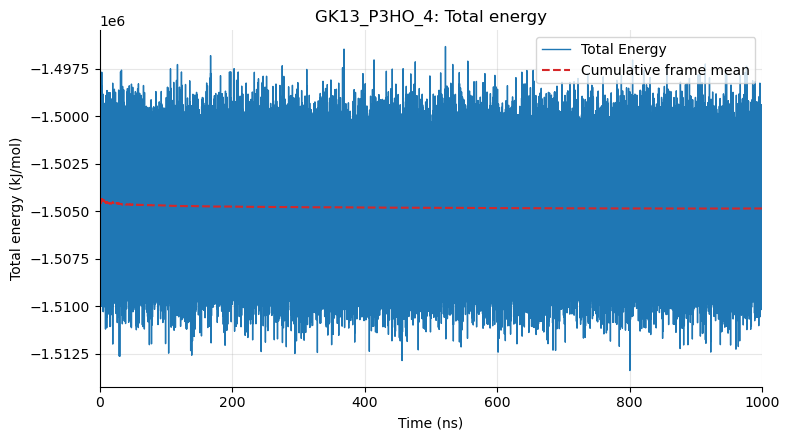

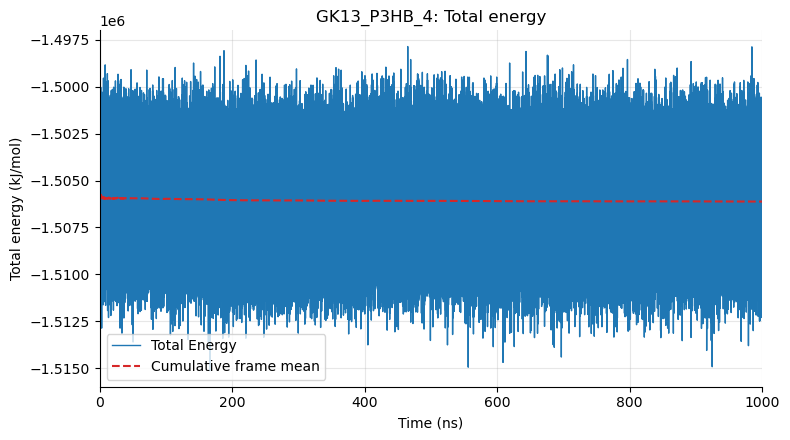

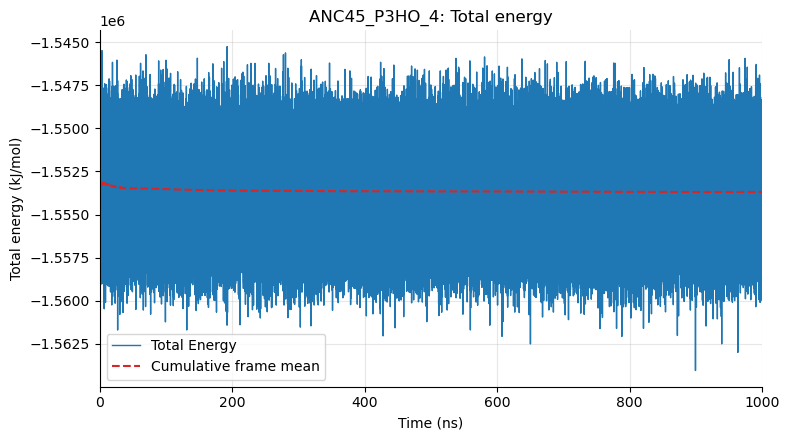

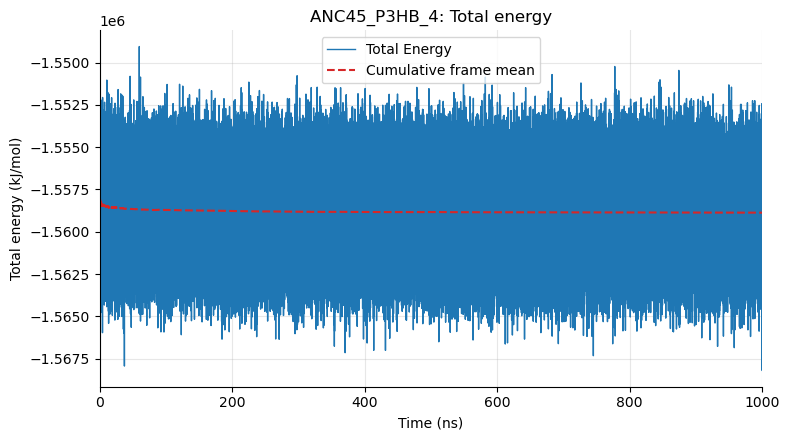

In [6]:
# Figure 1 — edit colours, labels, line widths and axes here, then rerun this cell.
for system in PLOT_SYSTEMS:
    data, prefix = load_plot_data(system, "total_energy", "total_energy_kj_mol")
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, data.total_energy_kj_mol, color="tab:blue", linewidth=1.0,
            label="Total Energy")
    ax.plot(data.time_ns, data.total_energy_kj_mol.expanding().mean(),
            color="tab:red", linestyle="--", linewidth=1.5, label="Cumulative frame mean")
    ax.set(xlabel="Time (ns)", ylabel="Total energy (kJ/mol)",
           title=f"{system.removesuffix('_gromacs')}: Total energy", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_total_energy.png", dpi=PNG_DPI)
    display(fig)
    plt.close(fig)


### Figure 2 — protein backbone RMSD

GK13_P3HO_4_gromacs: mean=1.6481 Å; SD=0.3363 Å; final 20% mean=2.0616 Å


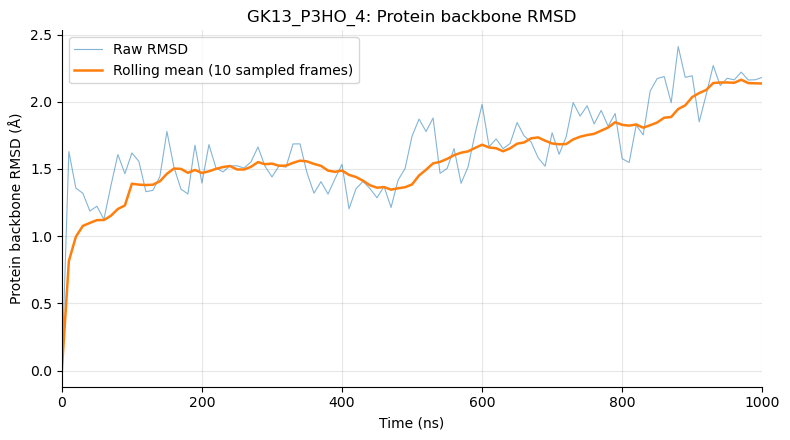

GK13_P3HB_4_gromacs: mean=2.3574 Å; SD=0.6436 Å; final 20% mean=2.5569 Å


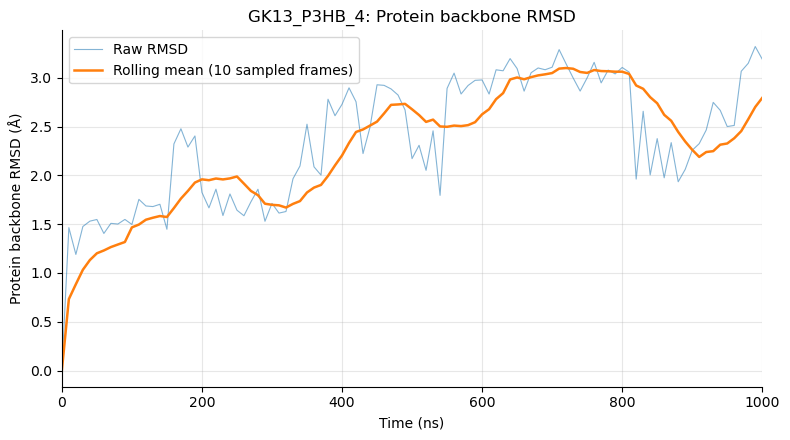

ANC45_P3HO_4_gromacs: mean=2.4890 Å; SD=0.4787 Å; final 20% mean=2.8028 Å


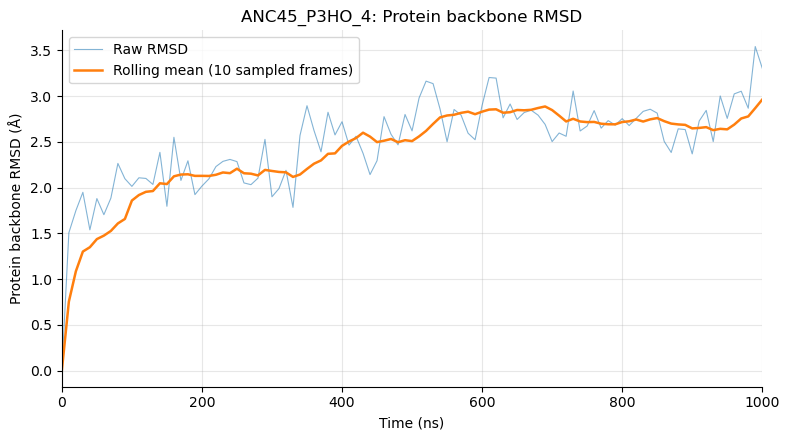

ANC45_P3HB_4_gromacs: mean=2.3816 Å; SD=0.4604 Å; final 20% mean=2.4000 Å


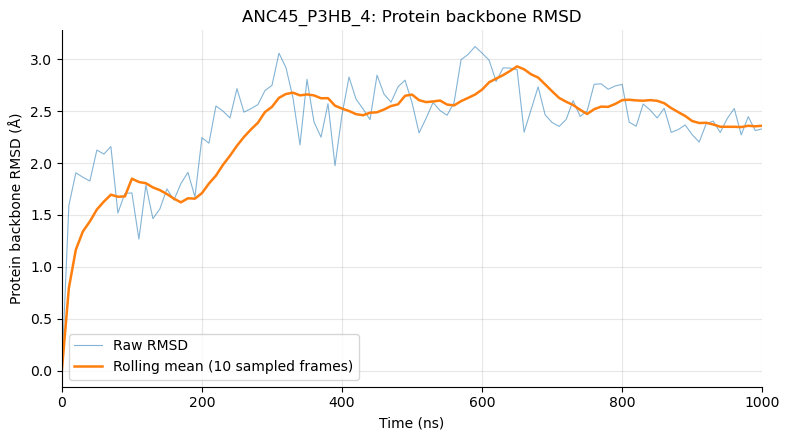

In [7]:
# Figure 2 — edit this cell and rerun it independently of the analysis.
for system in PLOT_SYSTEMS:
    data, prefix = load_plot_data(system, "protein_backbone_rmsd", "protein_backbone_rmsd_A")
    values = data["protein_backbone_rmsd_A"]
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, values, color="tab:blue", linewidth=0.8, alpha=0.55,
            label="Raw RMSD")
    if PLOT_ROLLING_WINDOW is not None:
        mean = values.rolling(PLOT_ROLLING_WINDOW, min_periods=1).mean()
        ax.plot(data.time_ns, mean, color="tab:orange", linewidth=1.8,
                label=f"Rolling mean ({PLOT_ROLLING_WINDOW} sampled frames)")
    ax.set(xlabel="Time (ns)", ylabel="Protein backbone RMSD (Å)",
           title=f"{system.removesuffix('_gromacs')}: Protein backbone RMSD", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_protein_backbone_rmsd.png", dpi=PNG_DPI)
    final_count = max(1, int(np.ceil(0.20 * len(values))))
    print(f"{system}: mean={values.mean():.4f} Å; SD={values.std():.4f} Å; "
          f"final 20% mean={values.iloc[-final_count:].mean():.4f} Å")
    display(fig)
    plt.close(fig)


### Figure 3 — minimum enzyme–PHA distance

GK13_P3HO_4_gromacs: mean=8.3551 Å; SD=11.1384 Å; final 20% mean=10.4226 Å


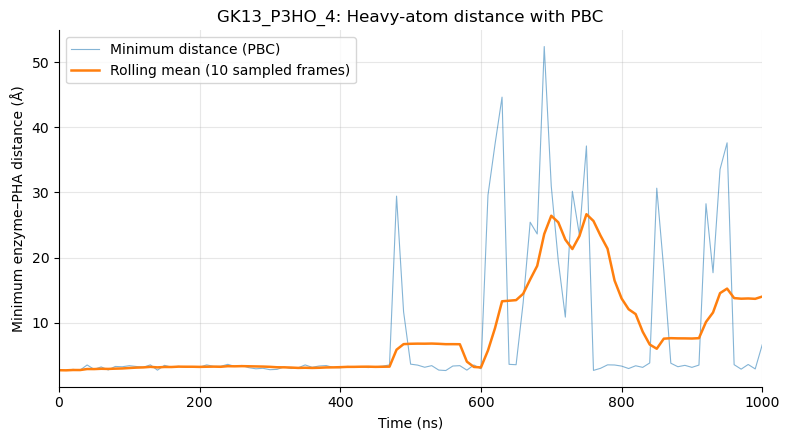

GK13_P3HB_4_gromacs: mean=21.8010 Å; SD=15.1224 Å; final 20% mean=21.4639 Å


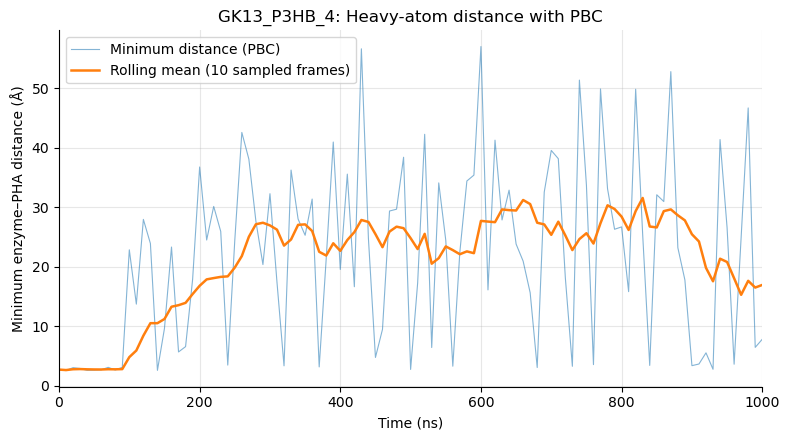

ANC45_P3HO_4_gromacs: mean=9.1214 Å; SD=13.7918 Å; final 20% mean=24.8388 Å


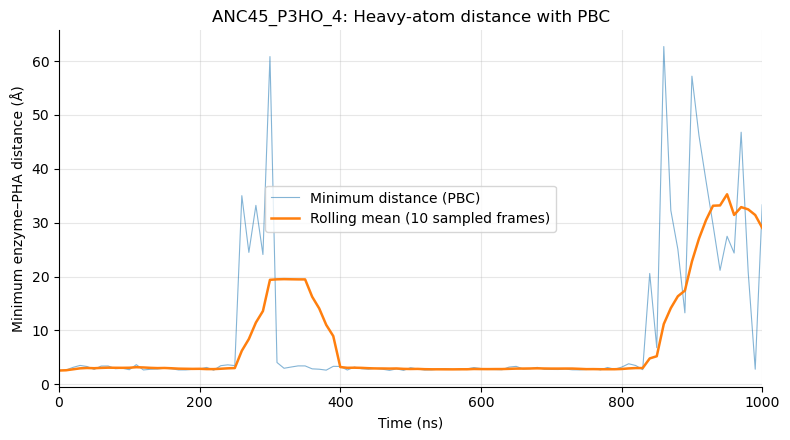

ANC45_P3HB_4_gromacs: mean=23.0263 Å; SD=14.3378 Å; final 20% mean=19.4521 Å


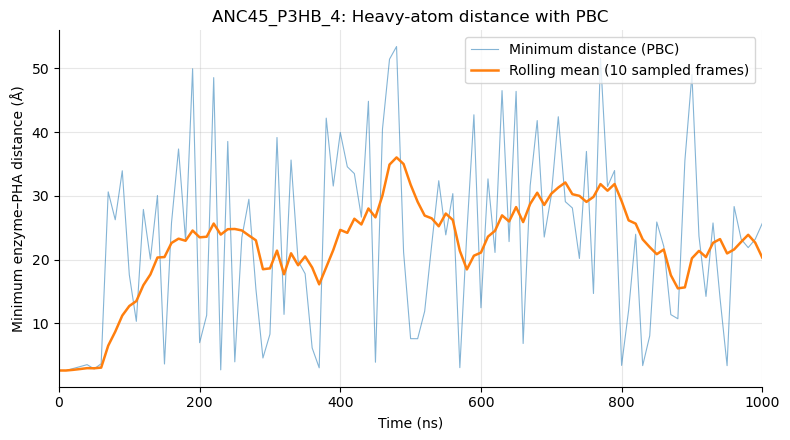

In [8]:
# Figure 3 — edit this cell and rerun it independently of the analysis.
for system in PLOT_SYSTEMS:
    data, prefix = load_plot_data(system, "enzyme_pha_min_distance", "enzyme_pha_min_distance_A")
    values = data["enzyme_pha_min_distance_A"]
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(data.time_ns, values, color="tab:blue", linewidth=0.8, alpha=0.55,
            label="Minimum distance (PBC)")
    if PLOT_ROLLING_WINDOW is not None:
        mean = values.rolling(PLOT_ROLLING_WINDOW, min_periods=1).mean()
        ax.plot(data.time_ns, mean, color="tab:orange", linewidth=1.8,
                label=f"Rolling mean ({PLOT_ROLLING_WINDOW} sampled frames)")
    ax.set(xlabel="Time (ns)", ylabel="Minimum enzyme–PHA distance (Å)",
           title=f"{system.removesuffix('_gromacs')}: Heavy-atom distance with PBC", xlim=(START_NS, END_NS))
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(f"{prefix}_enzyme_pha_min_distance.png", dpi=PNG_DPI)
    final_count = max(1, int(np.ceil(0.20 * len(values))))
    print(f"{system}: mean={values.mean():.4f} Å; SD={values.std():.4f} Å; "
          f"final 20% mean={values.iloc[-final_count:].mean():.4f} Å")
    display(fig)
    plt.close(fig)


## 6. Inspect and rerun

Each system's `analysis/` folder now contains `<system>_<OUTPUT_TAG>_total_energy.png/.csv`,
`..._protein_backbone_rmsd.png/.csv`, and `..._enzyme_pha_min_distance.png/.csv`, with the rolling-mean columns included in the RMSD/distance CSVs, plus an energy command log and a summary recording the selection and numerical checks.

A low minimum distance reports the closest atom pair, not how many contacts exist or whether the polymer is bound. Energy is a diagnostic; NPT total energy need not be conserved. No equilibration or convergence conclusion is made automatically. A stride of 100 can miss short-lived distance changes: reduce `STRIDE` and choose a new `OUTPUT_TAG` when finer sampling is needed.

Methods: [GROMACS energy](https://manual.gromacs.org/current/onlinehelp/gmx-energy.html),
[MDAnalysis RMSD](https://docs.mdanalysis.org/stable/documentation_pages/analysis/rms.html),
[periodic distance arrays](https://docs.mdanalysis.org/stable/documentation_pages/lib/distances.html).


The revised files use `<system>_research_0_1000ns_*`. Both RMSD and Figure 3 minimum distance are plotted and exported in Å. Energy remains in kJ/mol. Rolling means average the sampled per-frame minima and do not change their definition.

**To edit a plot after restarting the kernel:** run **1. Paths**, then **5. Plot settings**, then the individual **Figure 1, 2 or 3** code cell. You can skip sections 2–4. Change colours, labels, line widths and axes directly in that figure cell. Set `SAVE_FIGURES=False` to preview without saving. All plots keep the left/bottom borders and hide the top/right borders.

`PLOT_ROLLING_WINDOW` changes only the plotted rolling mean, recomputed cheaply from the saved per-frame values. Existing CSV rolling-mean columns still describe the original `ROLLING_WINDOW_FRAMES` recorded in the analysis summary. Changing trajectory stride, selections or calculation window requires running analysis again with a new output tag.